# Tema 2 · Regresión — Modelo de Liquidez
## Demo del viernes (resuelto) · Dataset: **Financial Statements (2009-2023)**

**Caso de negocio.** Un analista financiero quiere **estimar el nivel de liquidez**
de una empresa —medido con el **Current Ratio**— a partir de otros indicadores de
sus estados financieros (rentabilidad, márgenes, endeudamiento, flujos de caja).
El objetivo es anticipar riesgos de liquidez y entender **qué indicadores
explican mejor** la liquidez de la empresa.

> **Cómo se construye el target.** No hay un dataset "de liquidez" como tal:
> usamos la columna **`Current Ratio`** (ya calculada) como variable objetivo
> `y`, y el resto de indicadores financieros como predictores `X`.

Pipeline de la demo:
1. Carga y exploración
2. EDA: distribución del target y correlaciones
3. Selección de variables y split
4. Regresión lineal (baseline) vs. regularización (Ridge / Lasso)
5. Evaluación: MAE, RMSE, R² + diagnóstico de residuos
6. Multicolinealidad: **VIF**
7. Interpretación de coeficientes
8. Conclusión de negocio


## 0. Semilla personal (anti-copia)

In [1]:
cedula = 1020304050  # <-- reemplaza por tu número de cédula
import numpy as np
np.random.seed(cedula)
print(f"Semilla fijada en {cedula}")

Semilla fijada en 1020304050


## 1. Carga y exploración

El archivo trae un BOM y espacios en algunos nombres de columna → los limpiamos
al cargar.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../../data/03-regresion/financial_statements.csv")
df.columns = [c.strip().lstrip("\ufeff") for c in df.columns]  # limpia BOM y espacios
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (161, 23)


,Year,Company,Category,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,Cash Flow from Operating,Cash Flow from Investing,Cash Flow from Financial Activities,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)
0,2022,AAPL,IT,2066.94,394328.0,170782.0,99803.0,6.11,130541.0,50672.0,122151.0,-22354.0,-110749.0,0.8794,2.3695,196.9589,28.2924,66.6994,25.3096,1.3146,196.9589,164000,8.0028
1,2021,AAPL,IT,2913.28,365817.0,152836.0,94680.0,5.61,120233.0,63090.0,104038.0,-14545.0,-93353.0,1.0746,1.9768,150.0713,26.9742,54.9839,25.8818,1.3261,150.0713,154000,4.6979
2,2020,AAPL,IT,2255.97,274515.0,104956.0,57411.0,3.28,77344.0,65339.0,80674.0,-4289.0,-86820.0,1.3636,1.7208,87.8664,17.7256,35.0054,20.9136,1.0183,87.8664,147000,1.2336
3,2019,AAPL,IT,1304.76,260174.0,98392.0,55256.0,2.97,76477.0,90488.0,69391.0,45896.0,-90976.0,1.5401,1.1940,61.0645,16.3230,30.3113,21.2381,-0.0388,61.0645,137000,1.8122
4,2018,AAPL,IT,748.54,265595.0,101839.0,59531.0,2.98,81801.0,107147.0,77434.0,16066.0,-87876.0,1.1329,1.0685,55.5601,16.2775,29.6348,22.4142,0.7414,55.5601,132000,2.4426


In [3]:
df = df.sample(frac=0.85, random_state=cedula).reset_index(drop=True)
print("Dimensiones tras el muestreo:", df.shape)
df.info()

Dimensiones tras el muestreo: (137, 23)
<class 'pandas.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 137 non-null    int64  
 1   Company                              137 non-null    str    
 2   Category                             137 non-null    str    
 3   Market Cap(in B USD)                 136 non-null    float64
 4   Revenue                              137 non-null    float64
 5   Gross Profit                         137 non-null    float64
 6   Net Income                           137 non-null    float64
 7   Earning Per Share                    137 non-null    float64
 8   EBITDA                               137 non-null    float64
 9   Share Holder Equity                  137 non-null    float64
 10  Cash Flow from Operating             137 non-null    float64
 11  Cas

## 2. EDA: distribución del target y correlaciones

**Target = `Current Ratio`.** Un Current Ratio > 1 significa que la empresa tiene
más activos corrientes que pasivos corrientes (buena liquidez a corto plazo).

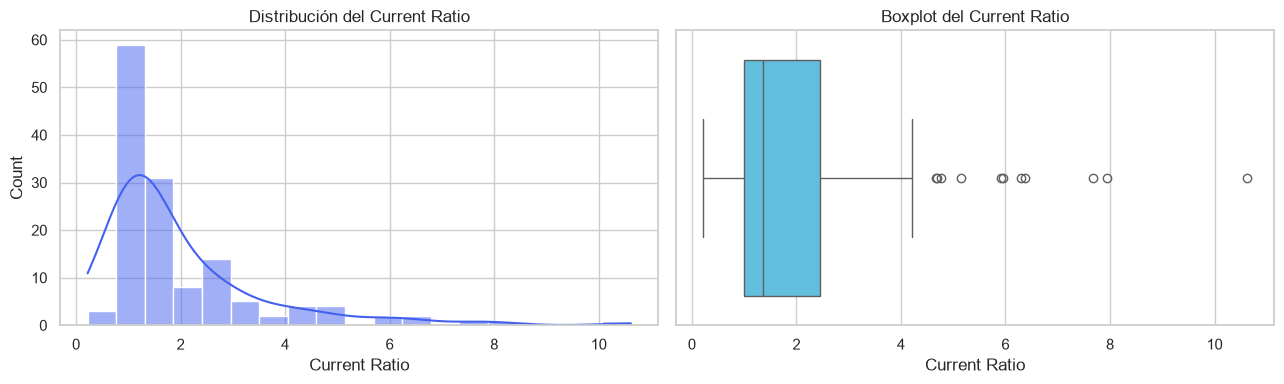

count    137.000
mean       2.004
std        1.611
min        0.220
25%        1.000
50%        1.353
75%        2.449
max       10.618
Name: Current Ratio, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["Current Ratio"], kde=True, ax=axes[0], color="#4361ee")
axes[0].set_title("Distribución del Current Ratio")
sns.boxplot(x=df["Current Ratio"], ax=axes[1], color="#4cc9f0")
axes[1].set_title("Boxplot del Current Ratio")
plt.tight_layout(); plt.show()
print(df["Current Ratio"].describe().round(3))

### Correlaciones con el target
Seleccionamos las variables numéricas y vemos cuáles se relacionan más con la
liquidez.

/var/folders/85/0szcbmmj5k95y52wkqp63pzc0000gr/T/ipykernel_81143/3421628219.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")


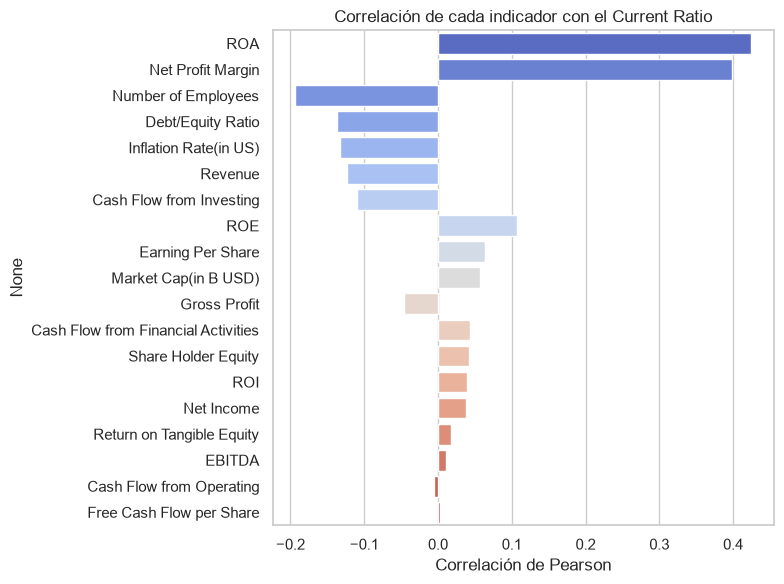

ROA                                    0.425
Net Profit Margin                      0.398
Number of Employees                   -0.193
Debt/Equity Ratio                     -0.137
Inflation Rate(in US)                 -0.133
Revenue                               -0.124
Cash Flow from Investing              -0.109
ROE                                    0.108
Earning Per Share                      0.064
Market Cap(in B USD)                   0.057
Gross Profit                          -0.047
Cash Flow from Financial Activities    0.043
Share Holder Equity                    0.042
ROI                                    0.039
Net Income                             0.037
Return on Tangible Equity              0.018
EBITDA                                 0.010
Cash Flow from Operating              -0.005
Free Cash Flow per Share               0.002
Name: Current Ratio, dtype: float64

In [5]:
num = df.select_dtypes("number").drop(columns=["Year"], errors="ignore")
corr_target = (num.corr()["Current Ratio"].drop("Current Ratio")
                  .sort_values(key=abs, ascending=False))
plt.figure(figsize=(8, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")
plt.title("Correlación de cada indicador con el Current Ratio")
plt.xlabel("Correlación de Pearson")
plt.tight_layout(); plt.show()
corr_target.round(3)

### Heatmap de correlaciones entre predictores
Con muchos ratios financieros es común que estén **correlacionados entre sí**
(multicolinealidad), algo que revisaremos formalmente con el VIF.

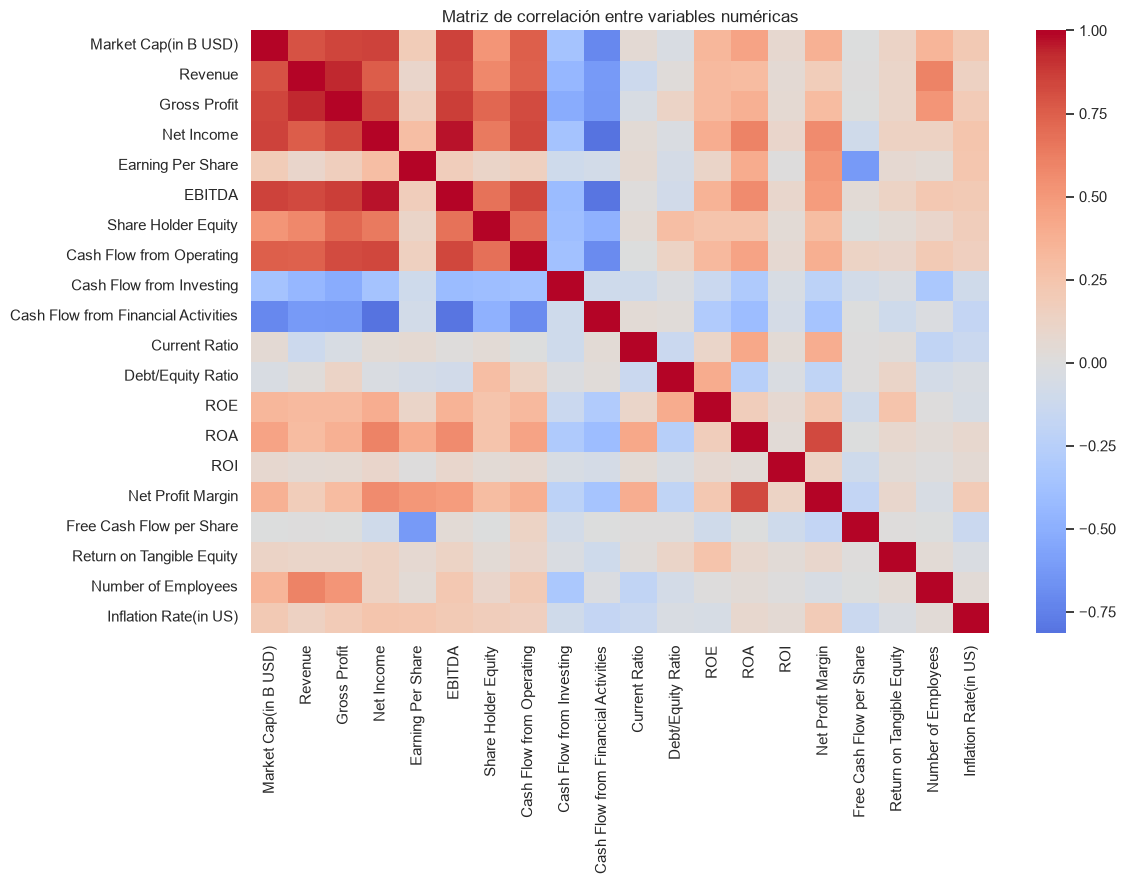

In [6]:
plt.figure(figsize=(12, 9))
sns.heatmap(num.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout(); plt.show()

## 3. Selección de variables y split

Usamos como predictores un conjunto de indicadores financieros
interpretables. Excluimos identificadores (`Year`) y columnas de texto
(`Company`, `Category`). Imputamos el único nulo con la mediana.

In [7]:
features = ["Revenue", "Gross Profit", "Net Income", "EBITDA",
            "Share Holder Equity", "Debt/Equity Ratio", "ROE", "ROA", "ROI",
            "Net Profit Margin", "Cash Flow from Operating",
            "Number of Employees"]
target = "Current Ratio"

data = df[features + [target]].copy()
data = data.fillna(data.median(numeric_only=True))
X = data[features]
y = data[target]
print("X:", X.shape, "| y:", y.shape)

X: (137, 12) | y: (137,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=cedula
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (102, 12) | Test: (35, 12)


## 4. Modelos: Lineal vs. Ridge/Lasso

Con muchos predictores correlacionados, la **regularización** (Ridge, Lasso)
suele generalizar mejor que la regresión lineal simple. Escalamos las variables
dentro de un `Pipeline` (imprescindible para Ridge/Lasso).

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

models = {
    "Lineal": LinearRegression(),
    "Ridge":  Ridge(alpha=1.0, random_state=cedula),
    "Lasso":  Lasso(alpha=0.01, random_state=cedula, max_iter=10000),
}
pipes = {name: Pipeline([("scaler", StandardScaler()), ("model", m)])
         for name, m in models.items()}
for p in pipes.values():
    p.fit(X_train, y_train)
print("Modelos entrenados:", list(pipes.keys()))

Modelos entrenados: ['Lineal', 'Ridge', 'Lasso']


## 5. Evaluación: MAE, RMSE, R²

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rows = []
for name, p in pipes.items():
    pred = p.predict(X_test)
    rows.append({
        "Modelo": name,
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2":   r2_score(y_test, pred),
    })
results = pd.DataFrame(rows).set_index("Modelo").round(4)
results

,MAE,RMSE,R2
Modelo,,,
Lineal,0.9537,1.1914,0.0527
Ridge,0.9388,1.1869,0.0599
Lasso,0.9233,1.1825,0.0667


### 5.1 Diagnóstico de residuos (modelo Ridge)
Un buen modelo de regresión debe tener residuos **sin patrón** (nube aleatoria
alrededor de 0) y **aproximadamente normales**.

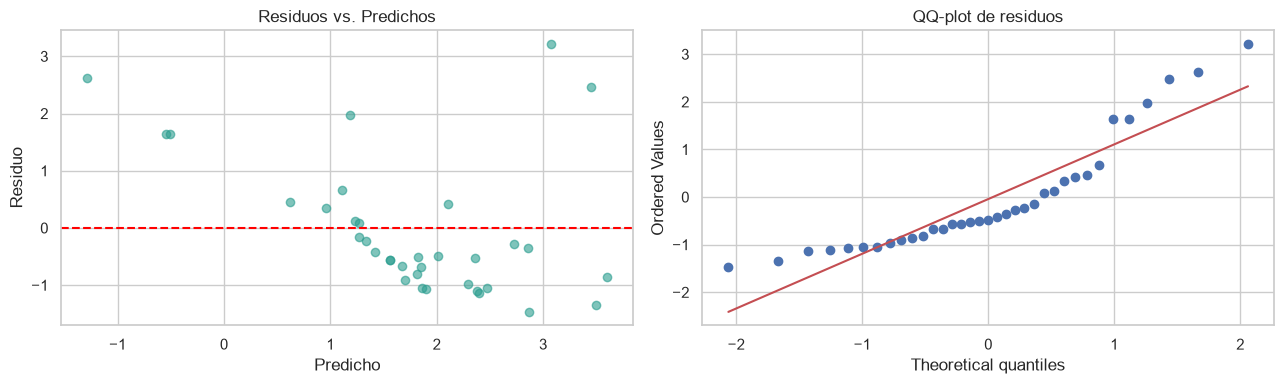

In [11]:
best = pipes["Ridge"]
pred = best.predict(X_test)
resid = y_test - pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(pred, resid, alpha=0.6, color="#2a9d8f")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Residuo")
axes[0].set_title("Residuos vs. Predichos")

import scipy.stats as stats
stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot de residuos")
plt.tight_layout(); plt.show()

## 6. Multicolinealidad: VIF (Variance Inflation Factor)

El **VIF** mide cuánto se infla la varianza de un coeficiente por su correlación
con las demás variables. Regla práctica: **VIF > 5-10 indica multicolinealidad
problemática**. Es un punto central con ratios financieros, que suelen moverse
juntos.

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

Xs = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
vif = pd.DataFrame({
    "Variable": Xs.columns,
    "VIF": [variance_inflation_factor(Xs.values, i) for i in range(Xs.shape[1])],
}).sort_values("VIF", ascending=False)
vif.round(2)

,Variable,VIF
3,EBITDA,30.08
2,Net Income,24.15
1,Gross Profit,20.56
0,Revenue,15.27
9,Net Profit Margin,4.99
10,Cash Flow from Operating,4.49
7,ROA,4.13
11,Number of Employees,4.07
4,Share Holder Equity,3.60
5,Debt/Equity Ratio,2.45


Las variables con VIF alto (p. ej. las de rentabilidad que se solapan)
son candidatas a reducir o combinar. En un modelo operativo, quitar redundancias
mejora la interpretabilidad de los coeficientes.

## 7. Interpretación de coeficientes

Con las variables escaladas, la **magnitud** del coeficiente indica la fuerza del
efecto y el **signo** su dirección.

/var/folders/85/0szcbmmj5k95y52wkqp63pzc0000gr/T/ipykernel_81143/3747133326.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, palette="vlag")


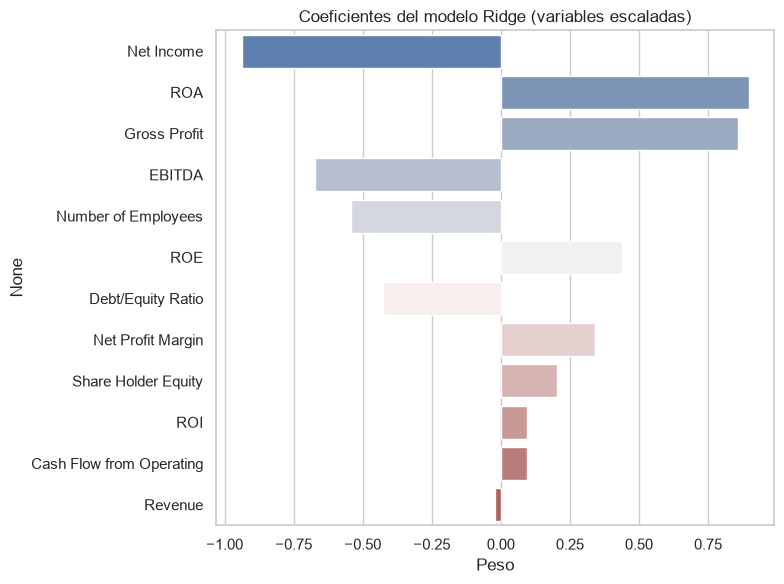

Net Income                 -0.9378
ROA                         0.8970
Gross Profit                0.8573
EBITDA                     -0.6742
Number of Employees        -0.5406
ROE                         0.4383
Debt/Equity Ratio          -0.4249
Net Profit Margin           0.3396
Share Holder Equity         0.2038
ROI                         0.0947
Cash Flow from Operating    0.0941
Revenue                    -0.0203
dtype: float64

In [13]:
coefs = pd.Series(best.named_steps["model"].coef_, index=X.columns)
coefs = coefs.sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=coefs.values, y=coefs.index, palette="vlag")
plt.title("Coeficientes del modelo Ridge (variables escaladas)")
plt.xlabel("Peso"); plt.tight_layout(); plt.show()
coefs.round(4)

## 8. Conclusión de negocio

- Los indicadores de **rentabilidad (ROA, Net Profit Margin)** y de
  **estructura de capital (Debt/Equity)** son los que más se asocian con la
  liquidez: empresas más rentables y menos apalancadas tienden a tener mejor
  Current Ratio.
- El **VIF** revela que varios ratios financieros están correlacionados entre sí;
  un modelo más parsimonioso (menos variables, o regularizado con Lasso) es más
  robusto e interpretable para el analista.
- **Ridge/Lasso** ayudan cuando hay muchos predictores correlacionados,
  reduciendo el sobreajuste frente a la lineal simple.

**Recomendación al analista financiero:** monitorear de cerca los indicadores de
rentabilidad y endeudamiento como señales tempranas de liquidez, y preferir un
modelo regularizado y parsimonioso para explicar sus decisiones.
